In [1]:
import os
import sys
import gc
import joblib
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# paths
X_PATH = "../data/processed/X_all.npy"
C_PATH = "../data/processed/C_all.npy"
SAVE_DIR = "../saved_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# import model.py from parent folder
sys.path.append(os.path.abspath(".."))
from src.model import FiLMAutoencoder

PyTorch version: 2.7.1+cu118
Device: cuda


In [2]:
# =========================
# LOAD DATA
# =========================
X_all = np.load(X_PATH, allow_pickle=False)
C_all = np.load(C_PATH, allow_pickle=False)

print("Loaded ✅")
print("X_all:", X_all.shape, X_all.dtype)
print("C_all:", C_all.shape, C_all.dtype)

assert X_all.ndim == 3, f"X_all must be 3D, got {X_all.ndim}D"
assert C_all.ndim == 2, f"C_all must be 2D, got {C_all.ndim}D"
assert len(X_all) == len(C_all), "X_all and C_all length mismatch"

if np.isnan(X_all).mean() > 0:
    print("NaNs found in X_all -> filling with 0")
    X_all = np.nan_to_num(X_all, nan=0.0)

print("Done loading data ✅")

Loaded ✅
X_all: (772049, 24, 8) float32
C_all: (772049, 5) float32
Done loading data ✅


In [3]:
# =========================
# TRAIN / VAL SPLIT
# =========================
X_tr, X_val, C_tr, C_val = train_test_split(
    X_all,
    C_all,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Split ✅")
print("X_tr :", X_tr.shape, "C_tr :", C_tr.shape)
print("X_val:", X_val.shape, "C_val:", C_val.shape)

Split ✅
X_tr : (617639, 24, 8) C_tr : (617639, 5)
X_val: (154410, 24, 8) C_val: (154410, 5)


In [4]:
# =========================
# SCALE X + SCALE CONTEXT
# =========================
scaler = RobustScaler(quantile_range=(25, 75))

N_tr, T, F = X_tr.shape
scaler.fit(X_tr.reshape(N_tr * T, F))

def apply_scaler(sc, X):
    N, T, F = X.shape
    X2 = sc.transform(X.reshape(N * T, F))
    return X2.reshape(N, T, F).astype(np.float32)

X_trs = apply_scaler(scaler, X_tr)
X_vals = apply_scaler(scaler, X_val)

ctx_scaler = StandardScaler()
C_tr = ctx_scaler.fit_transform(C_tr).astype(np.float32)
C_val = ctx_scaler.transform(C_val).astype(np.float32)

joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.joblib"))
joblib.dump(ctx_scaler, os.path.join(SAVE_DIR, "ctx_scaler.joblib"))

WINDOW_SIZE = X_trs.shape[1]
N_FEATURES = X_trs.shape[2]
CTX_DIM = C_tr.shape[1]

TOPK = max(10, int(0.10 * (WINDOW_SIZE * N_FEATURES)))

print("Scaling completed ✅")
print("X_trs :", X_trs.shape, X_trs.dtype)
print("X_vals:", X_vals.shape, X_vals.dtype)
print("C_tr  :", C_tr.shape, C_tr.dtype)
print("C_val :", C_val.shape, C_val.dtype)
print("WINDOW_SIZE:", WINDOW_SIZE)
print("N_FEATURES :", N_FEATURES)
print("CTX_DIM    :", CTX_DIM)
print("TOPK       :", TOPK)

Scaling completed ✅
X_trs : (617639, 24, 8) float32
X_vals: (154410, 24, 8) float32
C_tr  : (617639, 5) float32
C_val : (154410, 5) float32
WINDOW_SIZE: 24
N_FEATURES : 8
CTX_DIM    : 5
TOPK       : 19


In [5]:
# =========================
# NUMPY -> TORCH DATASETS
# =========================
X_tr_t = torch.tensor(X_trs, dtype=torch.float32)
C_tr_t = torch.tensor(C_tr, dtype=torch.float32)
X_val_t = torch.tensor(X_vals, dtype=torch.float32)
C_val_t = torch.tensor(C_val, dtype=torch.float32)

BATCH_SIZE = 128

train_ds = TensorDataset(X_tr_t, C_tr_t)
val_ds = TensorDataset(X_val_t, C_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("DataLoaders ready ✅")
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

DataLoaders ready ✅
Train batches: 4826
Val batches  : 1207


In [6]:
# =========================
# BUILD MODEL
# =========================
model = FiLMAutoencoder(
    window_size=WINDOW_SIZE,
    n_features=N_FEATURES,
    context_dim=CTX_DIM,
    units=64,
    latent=64
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=4,
    factor=0.5
)

print(model)

FiLMAutoencoder(
  (enc1): FiLMBlock(
    (conv): Conv1d(8, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (film): FiLM(
      (modulation): Linear(in_features=5, out_features=128, bias=True)
    )
    (act): ReLU()
  )
  (enc2): FiLMBlock(
    (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (film): FiLM(
      (modulation): Linear(in_features=5, out_features=128, bias=True)
    )
    (act): ReLU()
  )
  (gap): AdaptiveAvgPool1d(output_size=1)
  (z): Linear(in_features=64, out_features=64, bias=True)
  (dec_dense): Linear(in_features=64, out_features=1536, bias=True)
  (dec1): FiLMBlock(
    (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (film): FiLM(
      (modulation): Linear(in_features=5, out_features=128, bias=True)
    )
    (act): ReLU()
  )
  (dec_conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (dec_act): ReLU()
  (out): Conv1d(64, 8, kernel_size=(3,), stride=(1,), padding=(1,))
)


In [7]:
from tqdm.auto import tqdm
import time

best_val = float("inf")
best_state = None
patience = 12
wait = 0
EPOCHS = 80

history = {
    "train_loss": [],
    "val_loss": [],
    "lr": [],
}

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ---- train ----
    model.train()
    train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch:03d} [train]", leave=False)
    for xb, cb in train_bar:
        xb = xb.to(device)
        cb = cb.to(device)

        optimizer.zero_grad()
        pred = model(xb, cb)
        loss = criterion(pred, xb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        train_bar.set_postfix(batch_loss=f"{loss.item():.6f}")

    train_loss /= len(train_loader.dataset)

    # ---- validation ----
    model.eval()
    val_loss = 0.0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch:03d} [val]", leave=False)
    with torch.no_grad():
        for xb, cb in val_bar:
            xb = xb.to(device)
            cb = cb.to(device)

            pred = model(xb, cb)
            loss = criterion(pred, xb)
            val_loss += loss.item() * xb.size(0)
            val_bar.set_postfix(batch_loss=f"{loss.item():.6f}")

    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.6f} | "
        f"val_loss={val_loss:.6f} | "
        f"lr={current_lr:.6e} | "
        f"time={time.time() - epoch_start:.1f}s",
        flush=True
    )

    # ---- early stopping ----
    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.", flush=True)
            break

# restore best weights
if best_state is not None:
    model.load_state_dict(best_state)

print("Training finished ✅", flush=True)
print("Best val loss:", best_val, flush=True)

Epoch 001 [train]:   0%|          | 0/4826 [00:00<?, ?it/s]

Epoch 001 [val]:   0%|          | 0/1207 [00:00<?, ?it/s]

Epoch 001 | train_loss=20793.518398 | val_loss=6.044295 | lr=1.000000e-03 | time=41.8s


Epoch 002 [train]:   0%|          | 0/4826 [00:00<?, ?it/s]

Epoch 002 [val]:   0%|          | 0/1207 [00:00<?, ?it/s]

...

Epoch 057 [val]:   0%|          | 0/1207 [00:00<?, ?it/s]

Epoch 057 | train_loss=0.907856 | val_loss=1.729349 | lr=6.250000e-05 | time=38.7s


Epoch 058 [train]:   0%|          | 0/4826 [00:00<?, ?it/s]

Epoch 058 [val]:   0%|          | 0/1207 [00:00<?, ?it/s]

Epoch 058 | train_loss=0.886127 | val_loss=1.764583 | lr=6.250000e-05 | time=40.0s
Early stopping triggered.
Training finished ✅
Best val loss: 1.5313374418285441


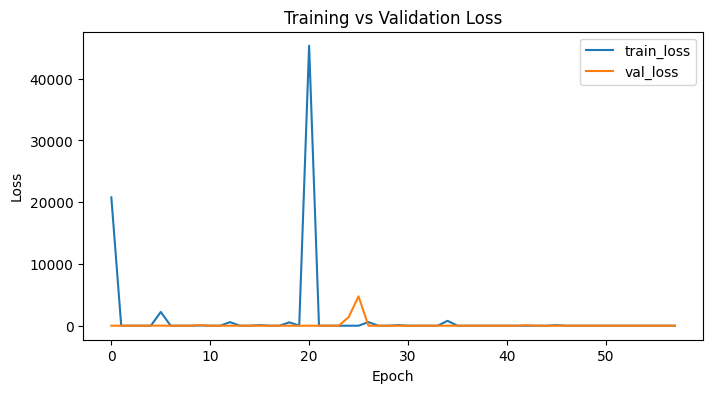

In [8]:
# =========================
# OPTIONAL: LOSS CURVE
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [9]:
# =========================
# TOP-K SCORE FUNCTION
# =========================
def topk_score(x_true, x_pred, k):
    err = (x_true - x_pred) ** 2
    flat = err.reshape(len(err), -1)
    k = min(k, flat.shape[1])
    part = np.partition(flat, -k, axis=1)[:, -k:]
    return np.mean(part, axis=1)

In [10]:
# =========================
# COMPUTE TRAIN THRESHOLD
# =========================
model.eval()
train_preds = []

with torch.no_grad():
    for xb, cb in train_loader:
        xb = xb.to(device)
        cb = cb.to(device)
        pred = model(xb, cb).cpu().numpy()
        train_preds.append(pred)

X_tr_pred = np.concatenate(train_preds, axis=0)
train_scores = topk_score(X_trs, X_tr_pred, TOPK)

THRESH = float(np.percentile(train_scores, 95))
detector_meta = {
    "topk": int(TOPK),
    "threshold": THRESH,
    "window_size": int(WINDOW_SIZE),
    "n_features": int(N_FEATURES),
    "context_dim": int(CTX_DIM),
}

joblib.dump(detector_meta, os.path.join(SAVE_DIR, "detector_meta.joblib"))

print("Threshold computed ✅")
print("Threshold:", THRESH)
print("Detector meta:", detector_meta)

Threshold computed ✅
Threshold: 412.6456298828125
Detector meta: {'topk': 19, 'threshold': 412.6456298828125, 'window_size': 24, 'n_features': 8, 'context_dim': 5}


In [11]:
# =========================
# SAVE PYTORCH MODEL
# =========================
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "window_size": WINDOW_SIZE,
        "n_features": N_FEATURES,
        "context_dim": CTX_DIM,
        "units": 64,
        "latent": 64,
    },
    os.path.join(SAVE_DIR, "ae_model.pt")
)

print("Saved model ✅ -> ../saved_model/ae_model.pt")
print("Saved scaler ✅ -> ../saved_model/scaler.joblib")
print("Saved ctx scaler ✅ -> ../saved_model/ctx_scaler.joblib")
print("Saved detector meta ✅ -> ../saved_model/detector_meta.joblib")

Saved model ✅ -> ../saved_model/ae_model.pt
Saved scaler ✅ -> ../saved_model/scaler.joblib
Saved ctx scaler ✅ -> ../saved_model/ctx_scaler.joblib
Saved detector meta ✅ -> ../saved_model/detector_meta.joblib


In [12]:
# =========================
# QUICK SANITY CHECK
# =========================
with torch.no_grad():
    xb, cb = next(iter(val_loader))
    xb = xb.to(device)
    cb = cb.to(device)
    pred = model(xb, cb)

print("Input shape :", xb.shape)
print("Output shape:", pred.shape)
print("Sanity check passed ✅")

Input shape : torch.Size([128, 24, 8])
Output shape: torch.Size([128, 24, 8])
Sanity check passed ✅
